# Lead Optimization (LO) Workflow — Series / SAR Analysis

**Dataset:** 1015 compounds across 15 chemical series, synthesized 2001–2007

**Columns:** `DATE`, `CPD_ID`, `SERIES_ID`, `SMILES`, `pKi`, `LogD (pH 7.40)`, `Solubility (pH 7.40) (uM)`

This notebook demonstrates a typical medicinal chemistry lead optimization
review: tracking how chemical series evolve over time on the key axes
that matter in LO — potency (pKi), lipophilicity (LogD), and solubility —
plus multi-parameter tradeoffs and simple SAR summaries per series.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

## 1. Load & prepare data

In [2]:
df = pd.read_csv('/mnt/user-data/uploads/data.csv')
df.columns = ['DATE', 'CPD_ID', 'SERIES_ID', 'SMILES', 'pKi', 'LogD', 'Sol_uM']
df['DATE'] = pd.to_datetime(df['DATE'])
df['LogSol'] = np.log10(df['Sol_uM'].clip(lower=0.1))  # avoid log(0)
df = df.sort_values('DATE').reset_index(drop=True)

df.head()

,DATE,CPD_ID,SERIES_ID,SMILES,pKi,LogD,Sol_uM,LogSol
0,2001-07-31,CPD_0,Aminoquinoline,Nc1nccc2ccc(CN3CC[C@H](NS(=O)(=O)c4cc5ncccc5s4...,6.563837,1.970,180.0,2.255273
1,2001-07-31,CPD_1,Ketopiperazine,O=C1CN(S(=O)(=O)c2cc3ccc(Cl)cc3s2)CCN1Cc1nc(-c...,5.767258,6.490,9.7,0.986772
2,2001-07-31,CPD_2,Ketopiperazine,CC(C)(C)c1csc(CN2CCN(S(=O)(=O)c3cc4ccc(Cl)cc4s...,6.119186,6.421,22.0,1.342423
3,2001-09-24,CPD_3,Indole,CC(C)N1CCC(NC(=O)c2cc3cc(F)cc(F)c3n2Cc2cc(-c3c...,9.022879,2.266,33.0,1.518514
4,2001-10-17,CPD_4,Indole,CC(C)N1CCC(NC(=O)c2c(Br)c3ccccc3n2Cc2cc(-c3ccc...,8.610924,2.455,81.0,1.908485


Focus on series with enough compounds (n≥20) for meaningful SAR trend analysis.

In [3]:
series_counts = df['SERIES_ID'].value_counts()
major_series = series_counts[series_counts >= 20].index.tolist()

print("Series with >=20 compounds (used for trend analysis):")
print(series_counts[series_counts >= 20])
print(f"\nTotal compounds: {len(df)} | Major series compounds: {df[df.SERIES_ID.isin(major_series)].shape[0]}")

palette = dict(zip(major_series, sns.color_palette("tab10", len(major_series))))

Series with >=20 compounds (used for trend analysis):
SERIES_ID
Indole            443
Azole12           298
Beta_aminoacid     62
Aminoquinoline     60
Taurine            41
Benzamidine        32
Ketopiperazine     22
Pyrrolidine        20
Name: count, dtype: int64

Total compounds: 1015 | Major series compounds: 978


## 2. Series activity timeline

When was each chemical series active, and how much synthetic effort went into each?

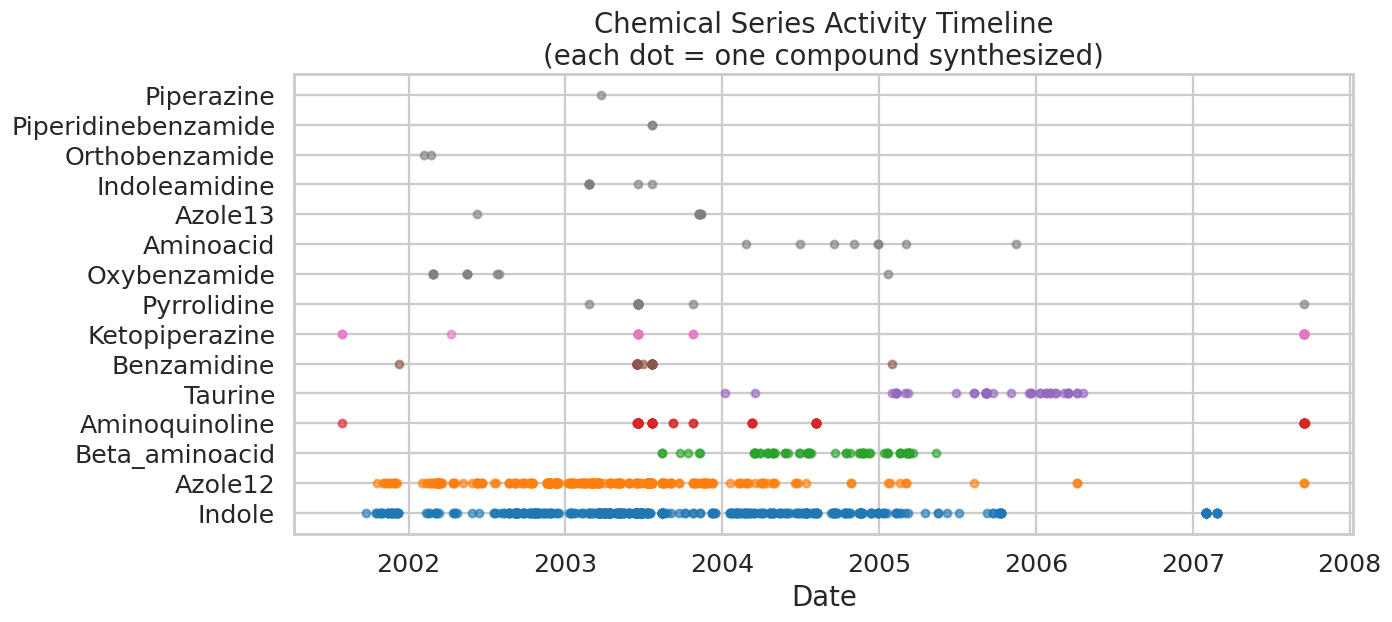

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))
for i, s in enumerate(series_counts.index):
    sub = df[df.SERIES_ID == s]
    ax.scatter(sub['DATE'], [i] * len(sub), s=25, alpha=0.6,
               color=palette.get(s, 'gray'), label=s)
ax.set_yticks(range(len(series_counts)))
ax.set_yticklabels(series_counts.index)
ax.set_xlabel("Date")
ax.set_title("Chemical Series Activity Timeline\n(each dot = one compound synthesized)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/lo_analysis_plots/01_series_timeline.png")
plt.show()

## 3. Potency (pKi) progression over time by series

The core LO progress plot: scatter of individual compounds plus a running
best-so-far line per series.

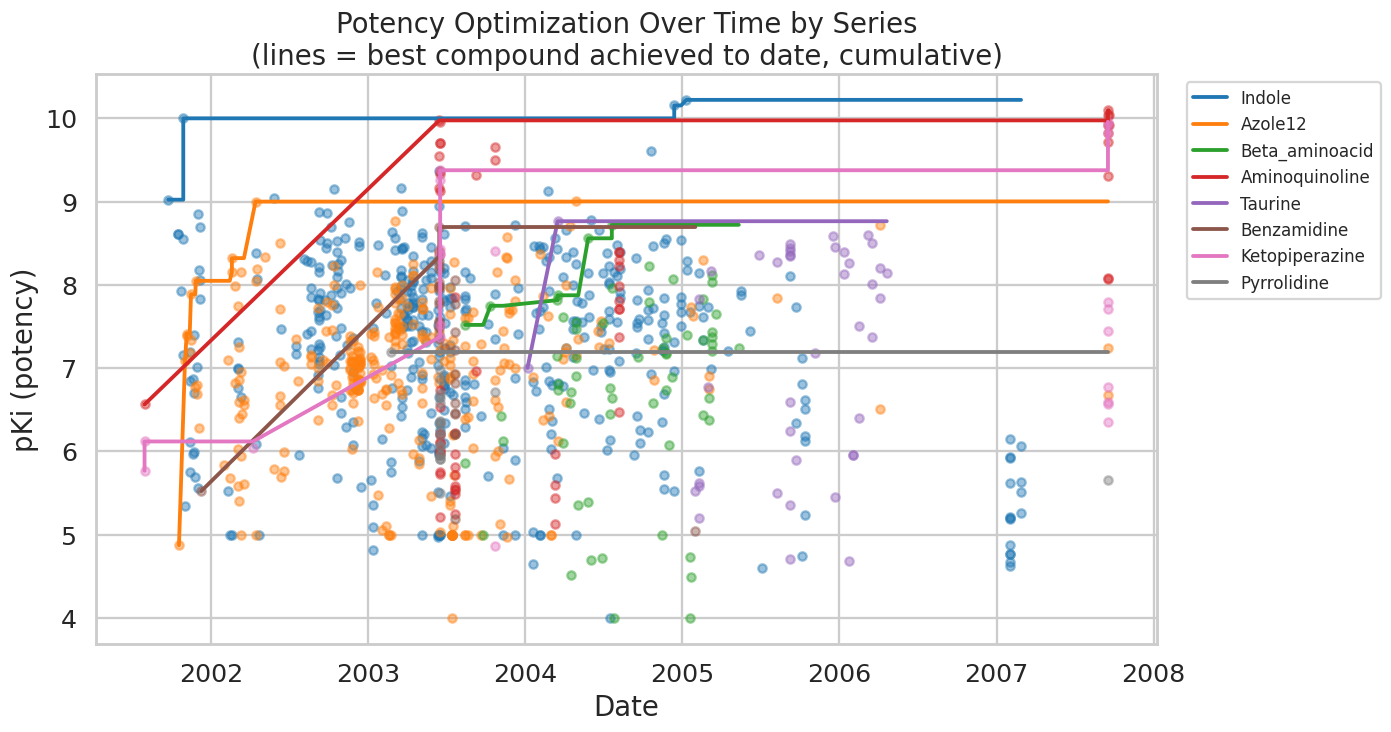

In [5]:
fig, ax = plt.subplots(figsize=(13, 7))
for s in major_series:
    sub = df[df.SERIES_ID == s].sort_values('DATE')
    ax.scatter(sub['DATE'], sub['pKi'], s=30, alpha=0.45, color=palette[s])
    # rolling max = "best compound so far" — the classic LO progress curve
    running_max = sub['pKi'].cummax()
    ax.plot(sub['DATE'], running_max, color=palette[s], linewidth=2.5, label=s)
ax.set_xlabel("Date")
ax.set_ylabel("pKi (potency)")
ax.set_title("Potency Optimization Over Time by Series\n(lines = best compound achieved to date, cumulative)")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/lo_analysis_plots/02_potency_progression.png")
plt.show()

## 4. Multi-parameter tradeoff: potency vs lipophilicity

The classic LO "triangle" plot — potency vs LogD, with point size
encoding solubility. The shaded band marks the generally preferred
LogD range (1–3) for drug-like compounds.

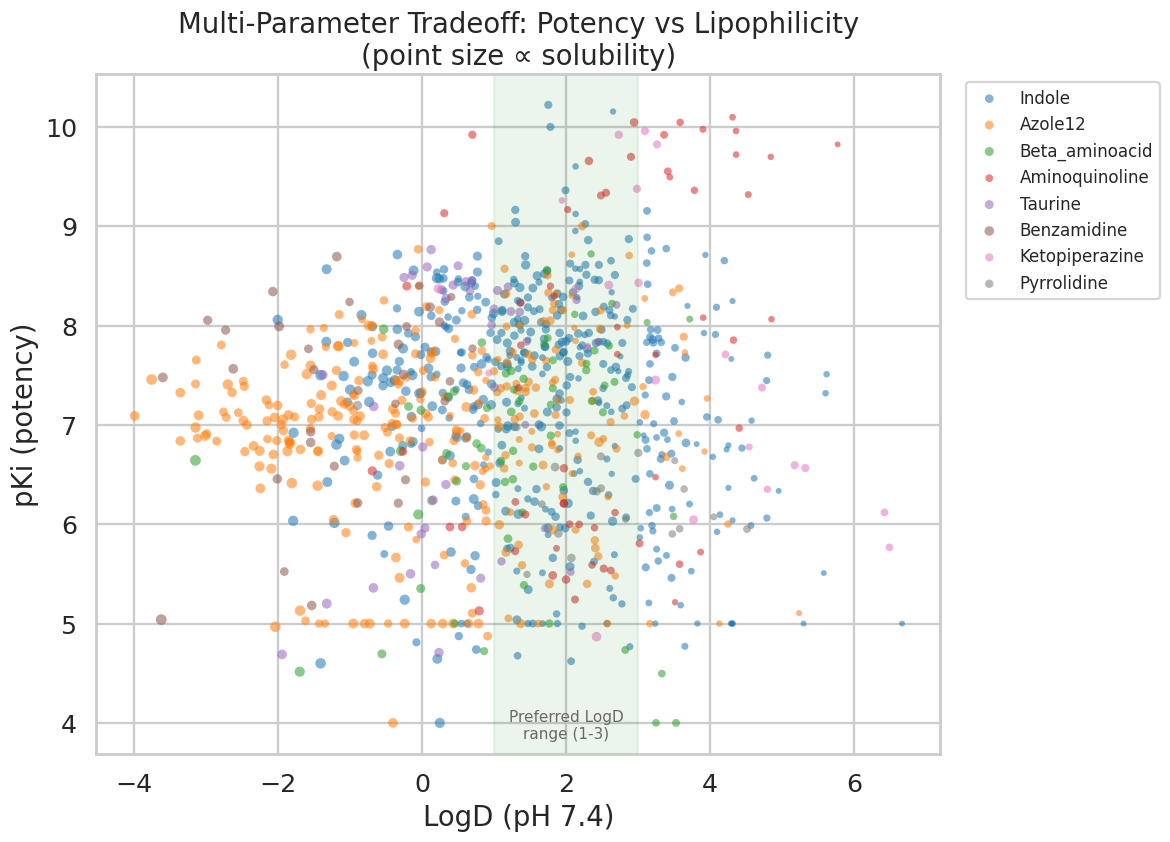

In [6]:
fig, ax = plt.subplots(figsize=(11, 8))
sub = df[df.SERIES_ID.isin(major_series)]
for s in major_series:
    ss = sub[sub.SERIES_ID == s]
    sizes = 15 + 35 * (ss['LogSol'] - df['LogSol'].min()) / (df['LogSol'].max() - df['LogSol'].min())
    ax.scatter(ss['LogD'], ss['pKi'], s=sizes, alpha=0.55, color=palette[s], label=s, edgecolors='none')
ax.axvspan(1, 3, alpha=0.08, color='green')
ax.text(2, ax.get_ylim()[0]+0.15, "Preferred LogD\nrange (1-3)", ha='center', fontsize=10, color='dimgray')
ax.set_xlabel("LogD (pH 7.4)")
ax.set_ylabel("pKi (potency)")
ax.set_title("Multi-Parameter Tradeoff: Potency vs Lipophilicity\n(point size ∝ solubility)")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/lo_analysis_plots/03_potency_vs_logd_tradeoff.png")
plt.show()

## 5. Solubility vs lipophilicity

The classic inverse relationship between LogD and aqueous solubility, per series.

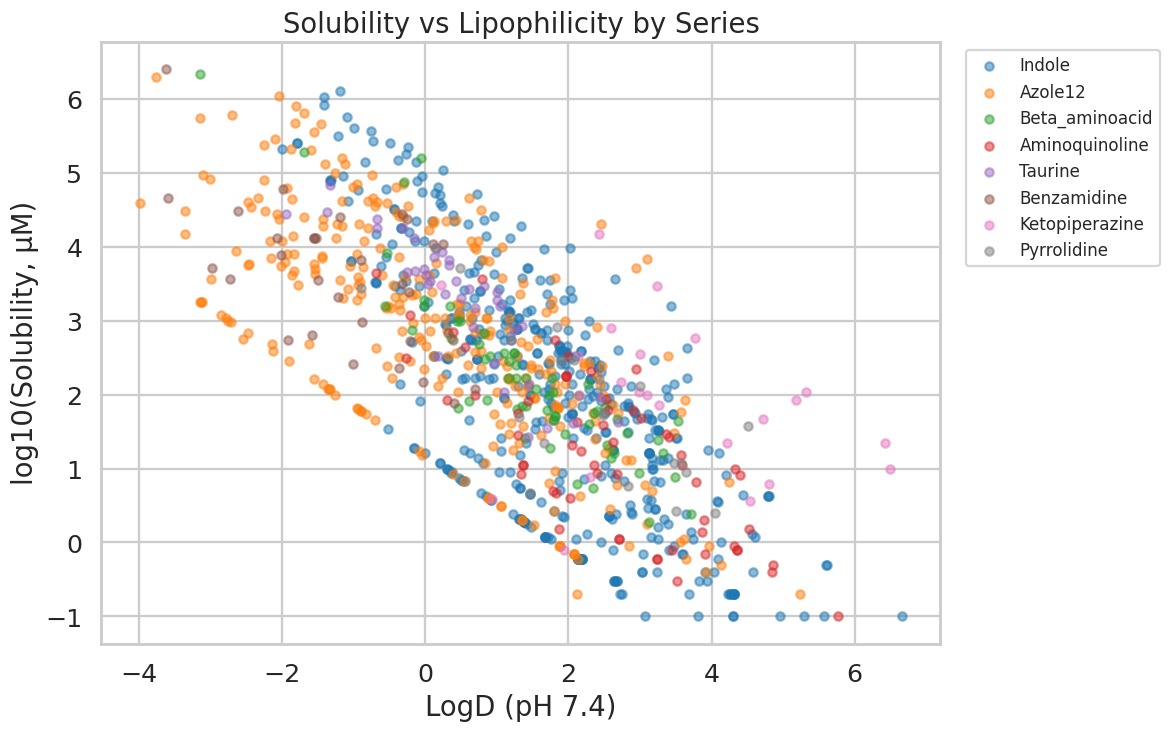

In [7]:
fig, ax = plt.subplots(figsize=(11, 7))
for s in major_series:
    ss = sub[sub.SERIES_ID == s]
    ax.scatter(ss['LogD'], ss['LogSol'], s=30, alpha=0.5, color=palette[s], label=s)
ax.set_xlabel("LogD (pH 7.4)")
ax.set_ylabel("log10(Solubility, µM)")
ax.set_title("Solubility vs Lipophilicity by Series")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/lo_analysis_plots/04_solubility_vs_logd.png")
plt.show()

## 6. Property distributions by series

Box plots comparing potency, lipophilicity, and solubility distributions
across the major chemical series.

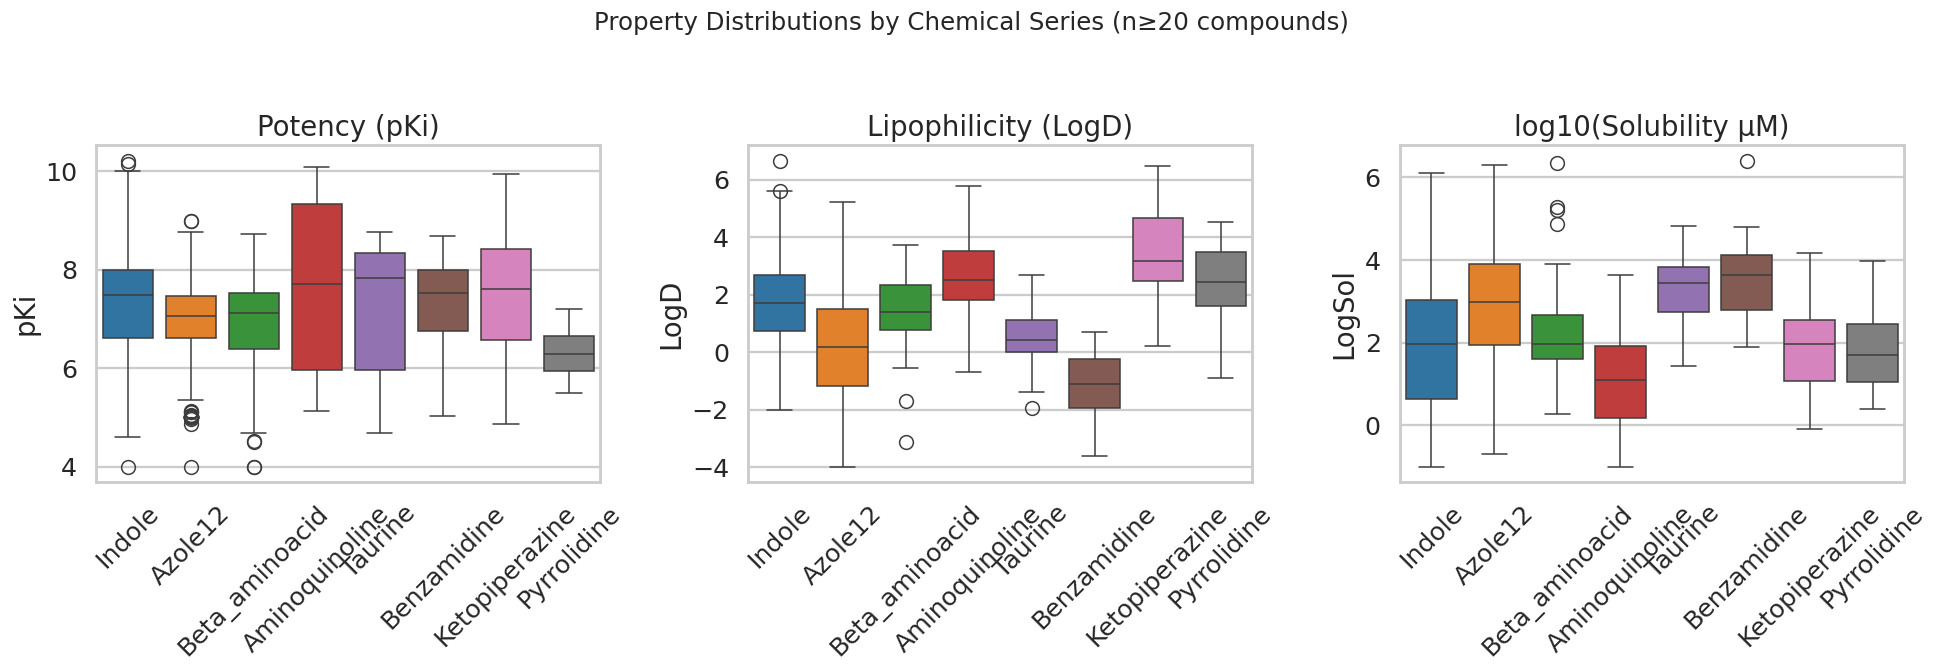

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
order = series_counts[series_counts >= 20].index.tolist()
for ax, col, title in zip(
    axes,
    ['pKi', 'LogD', 'LogSol'],
    ['Potency (pKi)', 'Lipophilicity (LogD)', 'log10(Solubility µM)']
):
    plot_df = df[df.SERIES_ID.isin(order)]
    sns.boxplot(data=plot_df, x='SERIES_ID', y=col, order=order, ax=ax,
                palette=palette, hue='SERIES_ID', legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
plt.suptitle("Property Distributions by Chemical Series (n≥20 compounds)", y=1.03, fontsize=16)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/lo_analysis_plots/05_series_property_distributions.png", bbox_inches='tight')
plt.show()

## 7. Synthesis cadence

Where was medicinal chemistry effort allocated over the course of the campaign?
Stacked bar chart of compounds synthesized per quarter, by series.

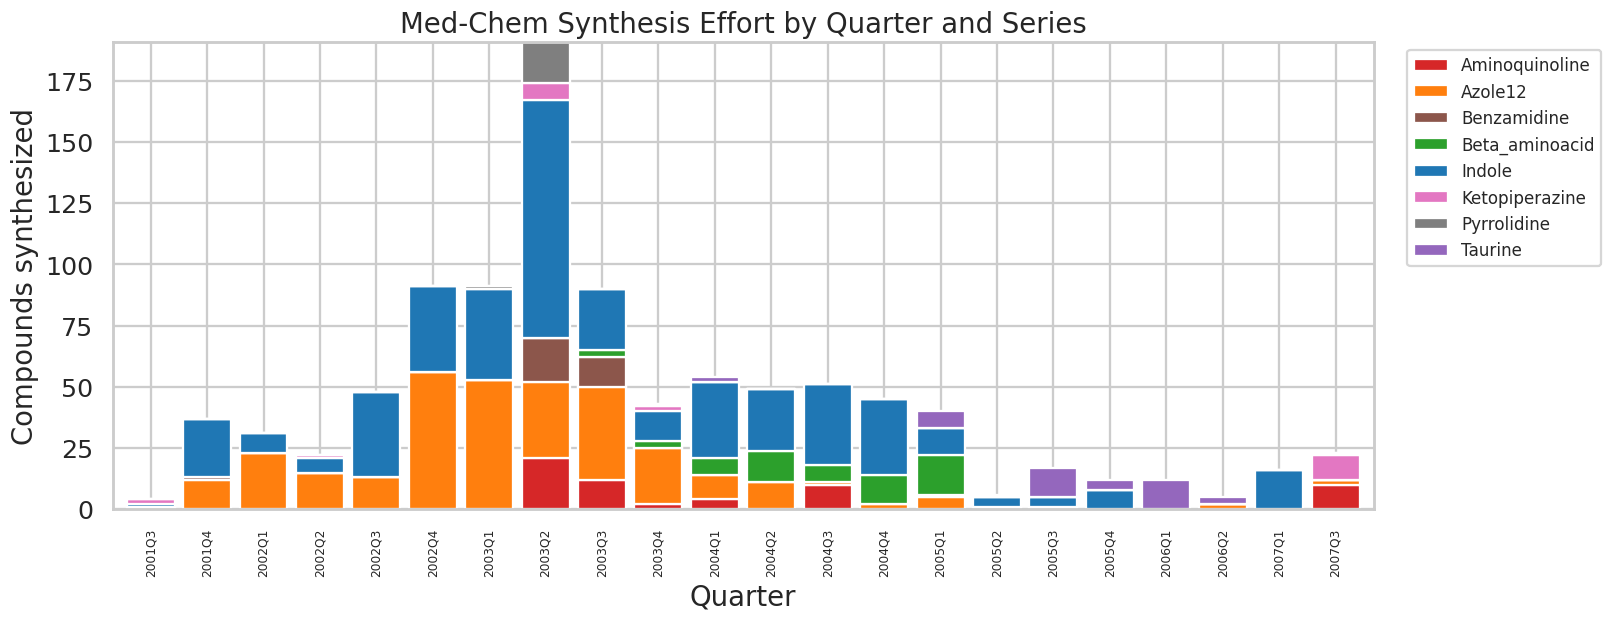

In [9]:
df['Quarter'] = df['DATE'].dt.to_period('Q')
q = df[df.SERIES_ID.isin(major_series)].groupby(['Quarter', 'SERIES_ID']).size().unstack(fill_value=0)
q.index = q.index.astype(str)

fig, ax = plt.subplots(figsize=(15, 6))
q.plot(kind='bar', stacked=True, ax=ax, color=[palette[c] for c in q.columns], width=0.85)
ax.set_xlabel("Quarter")
ax.set_ylabel("Compounds synthesized")
ax.set_title("Med-Chem Synthesis Effort by Quarter and Series")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/lo_analysis_plots/06_synthesis_cadence.png")
plt.show()

## 8. Summary statistics by series

In [10]:
summary = df[df.SERIES_ID.isin(major_series)].groupby('SERIES_ID').agg(
    n_compounds=('CPD_ID', 'count'),
    first_seen=('DATE', 'min'),
    last_seen=('DATE', 'max'),
    pKi_mean=('pKi', 'mean'),
    pKi_max=('pKi', 'max'),
    LogD_mean=('LogD', 'mean'),
    Sol_median_uM=('Sol_uM', 'median'),
).sort_values('n_compounds', ascending=False)
summary['pKi_mean'] = summary['pKi_mean'].round(2)
summary['pKi_max'] = summary['pKi_max'].round(2)
summary['LogD_mean'] = summary['LogD_mean'].round(2)
summary['Sol_median_uM'] = summary['Sol_median_uM'].round(0)
summary.to_csv("/mnt/user-data/outputs/lo_analysis_plots/series_summary.csv")

summary

,n_compounds,first_seen,last_seen,pKi_mean,pKi_max,LogD_mean,Sol_median_uM
SERIES_ID,,,,,,,
Indole,443,2001-09-24,2007-02-27,7.25,10.22,1.73,93.0
Azole12,298,2001-10-19,2007-09-17,6.95,9.00,0.18,950.0
Beta_aminoacid,62,2003-08-15,2005-05-12,6.77,8.72,1.41,92.0
Aminoquinoline,60,2001-07-31,2007-09-19,7.58,10.10,2.53,13.0
Taurine,41,2004-01-07,2006-04-21,7.20,8.76,0.52,2700.0
Benzamidine,32,2001-12-10,2005-01-31,7.32,8.69,-1.12,4350.0
Ketopiperazine,22,2001-07-31,2007-09-17,7.68,9.96,3.47,92.0
Pyrrolidine,20,2003-02-24,2007-09-17,6.31,7.20,2.30,51.0


## Takeaways

- **Indole** and **Azole12** are the workhorse series (443 and 298 compounds),
  run in parallel across almost the whole 2001–2007 campaign.
- **Indole** achieved the highest ceiling potency (pKi 10.22) and stayed the
  team's main vehicle throughout.
- **Aminoquinoline** and **Ketopiperazine** are smaller series but hit very
  high peak potency (pKi ~10) with less volume — efficient scaffolds.
- **Azole12** is the most polar/soluble series (median 950 µM, mean LogD 0.18)
  but caps out lower on potency (max 9.0) — a classic potency/solubility tradeoff.
- **Benzamidine** sits at very low LogD (-1.12 mean) with high solubility but
  middling potency.